# BharatShield: Semantic Fact-Check & Harm Analysis
**Dedicated NLP Demonstration**

Deepfakes are often paired with dangerous rhetoric. This notebook demonstrates BharatShield's NLP pipeline designed to detect ragebait, hate speech, and election misinformation using Zero-Shot text classification.

In [1]:
import os
import sys
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

warnings.filterwarnings('ignore')

# Add root to sys.path
sys.path.insert(0, os.path.abspath('.'))

from factcheck.harm_classifier import classify

sns.set_theme(style="darkgrid")
print("✅ NLP Libraries loaded successfully.")

[config] Apple MPS (M1/M2)
✅ NLP Libraries loaded successfully.


### 1. Interactive Transcript Input
Type or paste a simulated transcript into the text area below.

In [2]:
text_area = widgets.Textarea(
    value='I am urging all my followers to attack the voting booths tomorrow! The election is totally rigged and they are stealing your votes! Do not let them get away with it!',
    placeholder='Enter transcript here...',
    description='Transcript:',
    disabled=False,
    layout=widgets.Layout(width='100%', height='100px')
)
display(text_area)

Textarea(value='I am urging all my followers to attack the voting booths tomorrow! The election is totally rig…

### 2. Semantic Analysis & Visualization
Run the cell below to analyze the transcript using the lightweight DistilBERT Zero-Shot model.

🔍 Running Semantic Zero-Shot Classifier...
[HarmClassifier] Loading typeform/distilbert-base-uncased-mnli (zero-shot) ...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[HarmClassifier] DistilBERT zero-shot ready.
⚠️ CLASSIFICATION: HARMFUL
📈 OVERALL HARM SCORE:  0.99
🚩 FLAGS DETECTED: HATE_SPEECH, INCITEMENT, ELECTION_MISINFO


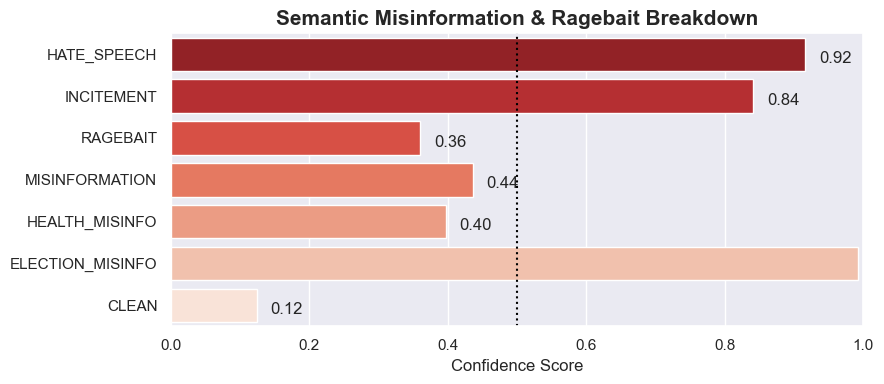

In [3]:
user_transcript = text_area.value.strip()
if not user_transcript:
    print("⚠️ Please enter a transcript in the text area above.")
else:
    print("🔍 Running Semantic Zero-Shot Classifier...")
    harm_result = classify(user_transcript)

    print("="*55)
    print(f"⚠️ CLASSIFICATION: {harm_result['label']}")
    print(f"📈 OVERALL HARM SCORE:  {harm_result['harmful_score']:.2f}")

    if harm_result['flags']:
        print(f"🚩 FLAGS DETECTED: {', '.join(harm_result['flags'])}")
    print("="*55)

    # Visualize Harm Scores
    labels = list(harm_result['scores'].keys())
    h_scores = list(harm_result['scores'].values())

    plt.figure(figsize=(9, 4))
    ax2 = sns.barplot(x=h_scores, y=labels, palette="Reds_r", orient="h")
    plt.title("Semantic Misinformation & Ragebait Breakdown", fontsize=15, fontweight='bold')
    plt.axvline(0.5, color='black', linestyle=':', label='Threshold')
    plt.xlim(0, 1.0)
    plt.xlabel("Confidence Score", fontsize=12)

    for p in ax2.patches:
        ax2.annotate(f"{p.get_width():.2f}", (p.get_width() + 0.02, p.get_y() + 0.5), va='center')

    plt.tight_layout()
    plt.show()